In [ ]:
!pip install gdown pycocotools matplotlib seaborn opencv-python

import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("DATA_DIR:", os.path.abspath(DATA_DIR))

DATA_DIR: /content/data


In [ ]:
import gdown
import os

file_id = "1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-"
url = f"https://drive.google.com/uc?id={file_id}"

anns_path = os.path.join("data", "annotations.json")
gdown.download(url, anns_path, quiet=False)

print("Downloaded annotations.json to:", os.path.abspath(anns_path))
print("Exists?", os.path.exists(anns_path))

Downloading...
From: https://drive.google.com/uc?id=1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-
To: /content/data/annotations.json
100%|██████████| 3.02M/3.02M [00:00<00:00, 20.5MB/s]

Downloaded annotations.json to: /content/data/annotations.json
Exists? True


In [ ]:
import os
import json
from PIL import Image, ImageOps
import requests
from io import BytesIO
import sys

DATASET_PATH = "./data/annotations.json"
dataset_dir = os.path.dirname(DATASET_PATH)

with open(DATASET_PATH, "r") as f:
    annotations = json.load(f)

nr_images = len(annotations["images"])
print("Number of images:", nr_images)

for i, image in enumerate(annotations["images"]):
    file_name = image["file_name"]
    url_original = image["flickr_url"]

    file_path = os.path.join(dataset_dir, file_name)
    subdir = os.path.dirname(file_path)
    os.makedirs(subdir, exist_ok=True)

    if not os.path.isfile(file_path):
        response = requests.get(url_original)
        img = Image.open(BytesIO(response.content))
        img.save(file_path)

    bar_size = 30
    x = int(bar_size * (i+1) / nr_images)
    sys.stdout.write("%s[%s%s] - %i/%i\r" %
                     ("Loading: ", "=" * x, "." * (bar_size - x), i+1, nr_images))
    sys.stdout.flush()

sys.stdout.write("\nFinished\n")

Number of images: 1500

Finished


10

In [ ]:
import json

with open("data/annotations.json") as f:
    taco = json.load(f)

images = taco["images"]
annotations = taco["annotations"]
categories = taco["categories"]

print("num images:", len(images))
print("num annotations:", len(annotations))
print("num categories:", len(categories))

print("\nSample image entry:")
print(images[0])

print("\nSample annotation entry:")
print(annotations[0])

print("\nSample category entry:")
print(categories[0])

num images: 1500
num annotations: 4784
num categories: 60

Sample image entry:
{'id': 0, 'width': 1537, 'height': 2049, 'file_name': 'batch_1/000006.jpg', 'license': None, 'flickr_url': 'https://farm66.staticflickr.com/65535/33978196618_e30a59e0a8_o.png', 'coco_url': None, 'date_captured': None, 'flickr_640_url': 'https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg'}

Sample annotation entry:
{'id': 1, 'image_id': 0, 'category_id': 6, 'segmentation': [[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0, 549.0, 1127.0, 538.0, 1089.0, 519.0, 1043.0, 517.0, 1005.0, 523.0, 964.0, 529.0, 945.0, 520.0, 896.0, 525.0, 862.0, 536.0, 821.0, 554.0, 769.0, 577.0, 727.0, 595.0, 678.0, 596.0, 585.0, 588.0, 346.0, 581.0, 328.0, 569.0, 306.0, 570.0, 276.0, 576.0, 224.0, 560.0, 205.0, 564.0, 170.0, 578.0, 154.0, 608.0, 136.0, 649.0, 127.0, 688.0, 127.0, 726.0, 129.0, 759.0, 141.0, 784.0, 153.0, 792.0, 177.0, 788.0, 193.0, 782.0, 209.0, 792.0, 238.0, 802.0, 271.0, 802.0, 294.0, 791.0, 319.0, 789

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cat_id_to_name = {c["id"]: c["name"] for c in categories}
cat_id_to_super = {c["id"]: c.get("supercategory", "unknown") for c in categories}

ann_df = pd.DataFrame(annotations)

ann_df["category_name"] = ann_df["category_id"].map(cat_id_to_name)
ann_df["supercategory"] = ann_df["category_id"].map(cat_id_to_super)

print("Annotations DataFrame shape:", ann_df.shape)
ann_df.head()

# CHECK NaN / MISSING VALUES

print("\n=== Missing values per column in ann_df ===")
print(ann_df.isna().sum())

print("\n=== Rows that contain at least one NaN ===")
nan_rows = ann_df[ann_df.isna().any(axis=1)]
print("Number of rows with NaN:", len(nan_rows))

if len(nan_rows) > 0:
    display(nan_rows.head(10))
else:
    print("No NaN rows found in annotations DataFrame.")

important_cols = ["id", "image_id", "category_id", "bbox"]
print("\n=== Missing values in important columns ===")
for col in important_cols:
    if col in ann_df.columns:
        print(f"{col}: {ann_df[col].isna().sum()}")
    else:
        print(f"{col}: column not found")

# STRUCTURAL VALIDATION OF ANNOTATIONS

print("\n=== Structural checks on annotations ===")

# 2.1 category_id
valid_cat_ids = set(cat_id_to_name.keys())
invalid_cat_rows = ann_df[~ann_df["category_id"].isin(valid_cat_ids)]
print("Invalid category_id rows:", len(invalid_cat_rows))

if len(invalid_cat_rows) > 0:
    display(invalid_cat_rows.head())

# 2.2 image_id
valid_image_ids = set([img["id"] for img in images])
invalid_image_rows = ann_df[~ann_df["image_id"].isin(valid_image_ids)]
print("Invalid image_id rows:", len(invalid_image_rows))

if len(invalid_image_rows) > 0:
    display(invalid_image_rows.head())

# 2.3 bbox
def invalid_bbox(bbox):
    if not isinstance(bbox, list) or len(bbox) != 4:
        return True
    x, y, w, h = bbox
    if w is None or h is None:
        return True
    if w <= 0 or h <= 0:
        return True
    return False

invalid_bbox_rows = ann_df[ann_df["bbox"].apply(invalid_bbox)]
print("Invalid bbox rows:", len(invalid_bbox_rows))

if len(invalid_bbox_rows) > 0:
    display(invalid_bbox_rows.head())

# 2.4 category_name that are not map
unmapped_category_rows = ann_df[ann_df["category_name"].isna()]
print("Rows with unmapped category_name:", len(unmapped_category_rows))

if len(unmapped_category_rows) > 0:
    display(unmapped_category_rows.head())


ann_df.head()

Annotations DataFrame shape: (4784, 9)

=== Missing values per column in ann_df ===
id               0
image_id         0
category_id      0
segmentation     0
area             0
bbox             0
iscrowd          0
category_name    0
supercategory    0
dtype: int64

=== Rows that contain at least one NaN ===
Number of rows with NaN: 0
No NaN rows found in annotations DataFrame.

=== Missing values in important columns ===
id: 0
image_id: 0
category_id: 0
bbox: 0

=== Structural checks on annotations ===
Invalid category_id rows: 0
Invalid image_id rows: 0
Invalid bbox rows: 0
Rows with unmapped category_name: 0


,id,image_id,category_id,segmentation,area,bbox,iscrowd,category_name,supercategory
0,1,0,6,"[[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0,...",403954.0,"[517.0, 127.0, 447.0, 1322.0]",0,Glass bottle,Bottle
1,2,1,18,"[[928.0, 1876.0, 938.0, 1856.0, 968.0, 1826.0,...",1071259.5,"[1.0, 457.0, 1429.0, 1519.0]",0,Meal carton,Carton
2,3,1,14,"[[617.0, 383.0, 703.0, 437.0, 713.0, 456.0, 72...",99583.5,"[531.0, 292.0, 1006.0, 672.0]",0,Other carton,Carton
3,4,2,5,"[[670.0, 993.0, 679.0, 998.0, 684.0, 1001.0, 6...",73832.5,"[632.0, 987.0, 500.0, 374.0]",0,Clear plastic bottle,Bottle
4,5,2,7,"[[647.0, 1028.0, 650.0, 1022.0, 653.0, 1016.0,...",915.0,"[632.0, 989.0, 44.0, 51.0]",0,Plastic bottle cap,Bottle cap


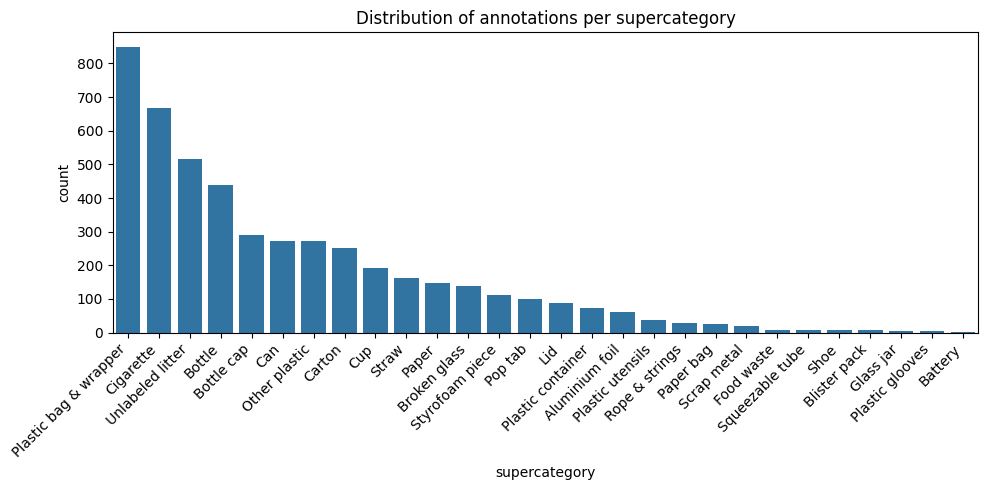

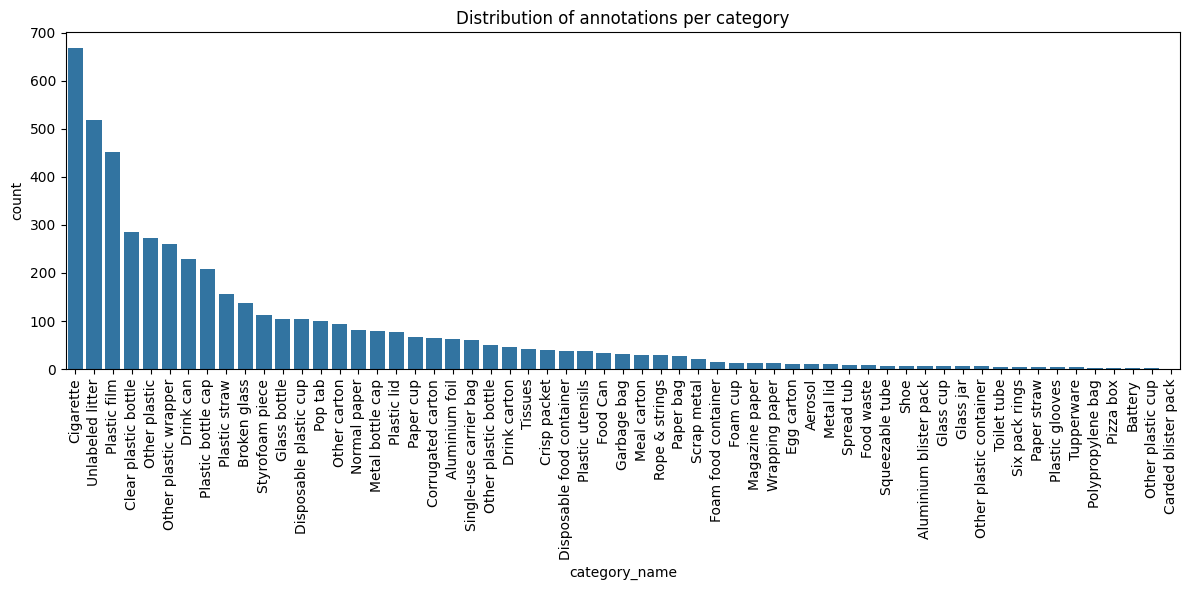

All categories (id, name, supercategory):


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Categories used in annotations:


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Category names (one per line):
- id= 0 | name=Aluminium foil | super=Aluminium foil
- id= 1 | name=Battery | super=Battery
- id= 2 | name=Aluminium blister pack | super=Blister pack
- id= 3 | name=Carded blister pack | super=Blister pack
- id= 4 | name=Other plastic bottle | super=Bottle
- id= 5 | name=Clear plastic bottle | super=Bottle
- id= 6 | name=Glass bottle | super=Bottle
- id= 7 | name=Plastic bottle cap | super=Bottle cap
- id= 8 | name=Metal bottle cap | super=Bottle cap
- id= 9 | name=Broken glass | super=Broken glass
- id=10 | name=Food Can | super=Can
- id=11 | name=Aerosol | super=Can
- id=12 | name=Drink can | super=Can
- id=13 | name=Toilet tube | super=Carton
- id=14 | name=Other carton | super=Carton
- id=15 | name=Egg carton | super=Carton
- id=16 | name=Drink carton | super=Carton
- id=17 | name=Corrugated carton | super=Carton
- id=18 | name=Meal carton | super=Carton
- id=19 | name=Pizza box | super=Carton
- id=20 | name=Paper cup | super=Cup
- id=21 | name=Disp

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=ann_df,
    x="supercategory",
    order=ann_df["supercategory"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of annotations per supercategory")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=ann_df,
    x="category_name",
    order=ann_df["category_name"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Distribution of annotations per category")
plt.tight_layout()
plt.show()


cat_df = pd.DataFrame(categories)
print("All categories (id, name, supercategory):")
display(cat_df[["id", "name", "supercategory"]].sort_values("id"))

used_cat_ids = sorted(ann_df["category_id"].unique())
used_cat_df = cat_df[cat_df["id"].isin(used_cat_ids)]

print("\nCategories used in annotations:")
display(used_cat_df[["id", "name", "supercategory"]].sort_values("id"))

print("\nCategory names (one per line):")
for _, row in used_cat_df.sort_values("id").iterrows():
    print(f"- id={row['id']:2d} | name={row['name']} | super={row['supercategory']}")

In [ ]:
recyclable = {
    "Aluminium foil",
    "Aluminium blister pack",
    "Carded blister pack",
    "Battery",
    "Other plastic bottle",
    "Clear plastic bottle",
    "Glass bottle",
    "Glass cup",
    "Plastic bottle cap",
    "Plastic film",
    "Metal bottle cap",
    "Food Can",
    "Aerosol",
    "Drink can",
    "Toilet tube",
    "Other carton",
    "Egg carton",
    "Drink carton",
    "Corrugated carton",
    "Meal carton",
    "Pizza box",
    "Magazine paper",
    "Wrapping paper",
    "Normal paper",
    "Paper bag",
    "Glass jar",
    "Metal lid",
    "Scrap metal",
    "Pop tab",
    "Polypropylene bag",
    "Plastic lid",
    "Spread tub",
    "Tupperware",
}
non_recyclable = {
    "Food waste",
    "Cigarette",
    "Broken glass",
    "Tissues",
    "Six pack rings",
    "Garbage bag",
    "Other plastic wrapper",
    "Single-use carrier bag",
    "Crisp packet",
    "Disposable plastic cup",
    "Foam cup",
    "Other plastic cup",
    "Foam food container",
    "Styrofoam piece",
    "Rope & strings",
    "Shoe",
    "Squeezable tube",
    "Plastic straw",
    "Paper straw",
    "Paper cup",
    "Plastic glooves",
    "Plastic utensils",
    "Other plastic",
    "Disposable food container",
    "Other plastic container",
}

CONF_THRESH_UNKNOWN = 0.35

def assign_recovery_bin(class_name: str, score: float) -> str:

    if score < CONF_THRESH_UNKNOWN:
        return "unknown"

    if class_name in recyclable:
        return "recyclable"
    elif class_name in non_recyclable:
        return "non_recyclable"
    else:
        return "unknown"

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split

IMAGES_ROOT = Path("data")
images_by_id = {img["id"]: img for img in images}

image_id_to_batch = {}

for img_id, img_rec in images_by_id.items():
    file_name = img_rec["file_name"]
    batch_name = Path(file_name).parts[0]
    image_id_to_batch[img_id] = batch_name

batches = sorted(set(image_id_to_batch.values()))
print("Total batches:", len(batches))
print(batches[:15])

train_batches, temp_batches = train_test_split(
    batches, test_size=0.30, random_state=42
)
val_batches, test_batches = train_test_split(
    temp_batches, test_size=0.50, random_state=42
)

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

train_image_ids = []
val_image_ids = []
test_image_ids = []

for img_id, batch_name in image_id_to_batch.items():
    if batch_name in train_batches:
        train_image_ids.append(img_id)
    elif batch_name in val_batches:
        val_image_ids.append(img_id)
    elif batch_name in test_batches:
        test_image_ids.append(img_id)

print("Train images:", len(train_image_ids))
print("Val images:", len(val_image_ids))
print("Test images:", len(test_image_ids))

def make_coco_subset(selected_image_ids, all_data):
    imgs = {img["id"]: img for img in all_data["images"]}

    subset_images = [imgs[i] for i in selected_image_ids]
    subset_image_id_set = set(selected_image_ids)

    subset_annotations = [
        ann for ann in all_data["annotations"]
        if ann["image_id"] in subset_image_id_set
    ]

    subset = {
        "info": all_data.get("info", {}),
        "licenses": all_data.get("licenses", []),
        "categories": all_data.get("categories", []),
        "images": subset_images,
        "annotations": subset_annotations,
    }
    return subset

train_data = make_coco_subset(train_image_ids, taco)
val_data   = make_coco_subset(val_image_ids, taco)
test_data  = make_coco_subset(test_image_ids, taco)

print("Train annotations:", len(train_data["annotations"]))
print("Val annotations:", len(val_data["annotations"]))
print("Test annotations:", len(test_data["annotations"]))

Total batches: 15
['batch_1', 'batch_10', 'batch_11', 'batch_12', 'batch_13', 'batch_14', 'batch_15', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7', 'batch_8', 'batch_9']
Train batches: ['batch_3', 'batch_11', 'batch_10', 'batch_9', 'batch_13', 'batch_2', 'batch_5', 'batch_7', 'batch_12', 'batch_15']
Val batches: ['batch_4', 'batch_8']
Test batches: ['batch_6', 'batch_14', 'batch_1']
Train images: 1013
Val images: 189
Test images: 298
Train annotations: 3291
Val annotations: 597
Test annotations: 896


In [ ]:
import json
from pathlib import Path

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

save_json(train_data, "data/splits/annotations_train.json")
save_json(val_data,   "data/splits/annotations_val.json")
save_json(test_data,  "data/splits/annotations_test.json")

print("All subset JSON files saved successfully.")


All subset JSON files saved successfully.


In [ ]:
s_train = set(train_image_ids)
s_val = set(val_image_ids)
s_test = set(test_image_ids)

print("train ∩ val:", len(s_train & s_val))
print("train ∩ test:", len(s_train & s_test))
print("val ∩ test:", len(s_val & s_test))

assert s_train.isdisjoint(s_val)
assert s_train.isdisjoint(s_test)
assert s_val.isdisjoint(s_test)

print("No overlap between splits")

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
No overlap between splits


In [ ]:
!pip install torch torchvision torchaudio torchmetrics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
from pathlib import Path
from PIL import Image

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
Device: cuda


In [ ]:
DATA_ROOT = Path("data")

TRAIN_JSON = DATA_ROOT / "splits" / "annotations_train.json"
VAL_JSON   = DATA_ROOT / "splits" / "annotations_val.json"
TEST_JSON  = DATA_ROOT / "splits" / "annotations_test.json"

print(TRAIN_JSON.exists(), VAL_JSON.exists(), TEST_JSON.exists())


True True True


In [ ]:
class TacoDetectionDataset(Dataset):
    def __init__(self, json_path, images_root, transforms=None):
        self.json_path = Path(json_path)
        self.images_root = Path(images_root)
        self.transforms = transforms

        with open(self.json_path, "r", encoding="utf-8") as f:
            self.data = json.load(f)

        self.images = self.data["images"]
        self.annotations = self.data["annotations"]
        self.categories = self.data["categories"]

        self.image_id_to_annotations = {}

        for ann in self.annotations:
            image_id = ann["image_id"]
            if image_id not in self.image_id_to_annotations:
                self.image_id_to_annotations[image_id] = []
            self.image_id_to_annotations[image_id].append(ann)

        self.cat_id_to_name = {cat["id"]: cat["name"] for cat in self.categories}
        self.num_original_classes = len(self.categories)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image_id = img_info["id"]
        file_name = img_info["file_name"]

        img_path = self.images_root / file_name
        image = Image.open(img_path).convert("RGB")

        anns = self.image_id_to_annotations.get(image_id, [])

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        width, height = image.size

        for ann in anns:
            x, y, w, h = ann["bbox"]

            xmin = x
            ymin = y
            xmax = x + w
            ymax = y + h

            # Clamp boxes to image boundaries
            xmin = max(0, min(xmin, width))
            xmax = max(0, min(xmax, width))
            ymin = max(0, min(ymin, height))
            ymax = max(0, min(ymax, height))

            # Skip invalid boxes after clamping
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])

            # Faster R-CNN reserves label 0 for background
            labels.append(ann["category_id"] + 1)

            areas.append(ann.get("area", w * h))
            iscrowd.append(ann.get("iscrowd", 0))

        if len(boxes) == 0:
             boxes = torch.zeros((0, 4), dtype=torch.float32)
             labels = torch.zeros((0,), dtype=torch.int64)
             areas = torch.zeros((0,), dtype=torch.float32)
             iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
             boxes = torch.as_tensor(boxes, dtype=torch.float32)
             labels = torch.as_tensor(labels, dtype=torch.int64)
             areas = torch.as_tensor(areas, dtype=torch.float32)
             iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)


        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target


In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = TacoDetectionDataset(
    json_path=TRAIN_JSON,
    images_root=DATA_ROOT
)

val_dataset = TacoDetectionDataset(
    json_path=VAL_JSON,
    images_root=DATA_ROOT
)

test_dataset = TacoDetectionDataset(
    json_path=TEST_JSON,
    images_root=DATA_ROOT
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)


Train samples: 1013
Val samples: 189
Test samples: 298


In [ ]:
images_batch, targets_batch = next(iter(train_loader))

print("Number of images in batch:", len(images_batch))
print("Image shape:", images_batch[0].shape)

print("Target keys:", targets_batch[0].keys())
print("Boxes shape:", targets_batch[0]["boxes"].shape)
print("Labels shape:", targets_batch[0]["labels"].shape)

print("Sample labels:", targets_batch[0]["labels"][:10])
print("Sample boxes:", targets_batch[0]["boxes"][:3])


Number of images in batch: 2
Image shape: torch.Size([3, 4160, 3120])
Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Boxes shape: torch.Size([4, 4])
Labels shape: torch.Size([4])
Sample labels: tensor([41, 59, 19, 59])
Sample boxes: tensor([[ 480., 3031., 2103., 4038.],
        [1504.,  609., 1821.,  811.],
        [1708.,  779., 2096., 1033.]])


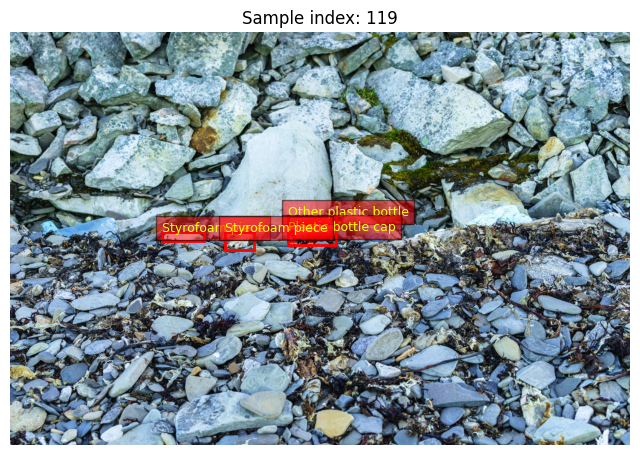

In [ ]:
def show_sample(dataset, idx=None):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    image, target = dataset[idx]

    image_np = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image_np)

    for box, label in zip(target["boxes"], target["labels"]):
        xmin, ymin, xmax, ymax = box.tolist()
        w = xmax - xmin
        h = ymax - ymin

        # label - 1 because model label = category_id + 1
        original_cat_id = int(label.item()) - 1
        class_name = dataset.cat_id_to_name.get(original_cat_id, "unknown")

        rect = patches.Rectangle(
            (xmin, ymin),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            class_name,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="red", alpha=0.5)
        )

    ax.set_title(f"Sample index: {idx}")
    ax.axis("off")
    plt.show()


show_sample(train_dataset)


In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT"
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    return model


NUM_CLASSES = 61  # 60 TACO classes + background

model = get_faster_rcnn_model(NUM_CLASSES)
model.to(device)

print(model.roi_heads.box_predictor)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 177MB/s]


FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=61, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=244, bias=True)
)


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    total_loss = 0.0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch}")

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        total_loss += loss_value

        progress_bar.set_postfix({
            "loss": f"{loss_value:.4f}",
            "avg_loss": f"{total_loss / (progress_bar.n + 1):.4f}"
        })

    avg_loss = total_loss / len(data_loader)
    return avg_loss


In [ ]:
@torch.no_grad()
def evaluate_loss(model, data_loader, device):
    model.train()

    total_loss = 0.0

    for images, targets in tqdm(data_loader, desc="Validation loss"):
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)
    return avg_loss


In [ ]:
common_loader_kwargs = dict(
    num_workers=0,
    pin_memory=False,
    persistent_workers=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
    **common_loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    **common_loader_kwargs
)


In [ ]:
NUM_EPOCHS = 10

best_val_loss = float("inf")
save_path = "faster_rcnn_taco_best.pth"

train_losses = []
val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model=model,
        optimizer=optimizer,
        data_loader=train_loader,
        device=device,
        epoch=epoch
    )

    val_loss = evaluate_loss(
        model=model,
        data_loader=val_loader,
        device=device
    )

    lr_scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}]")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved to: {save_path}")


Epoch 1:   0%|          | 0/507 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/95 [00:00<?, ?it/s]


Epoch [1/10]
Train loss: 0.4462
Val loss:   0.5267
Best model saved to: faster_rcnn_taco_best.pth


Epoch 2:   0%|          | 0/507 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/95 [00:00<?, ?it/s]

...

Validation loss:   0%|          | 0/95 [00:00<?, ?it/s]


Epoch [9/10]
Train loss: 0.3988
Val loss:   0.5259


Epoch 10:   0%|          | 0/507 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/95 [00:00<?, ?it/s]


Epoch [10/10]
Train loss: 0.3983
Val loss:   0.5280


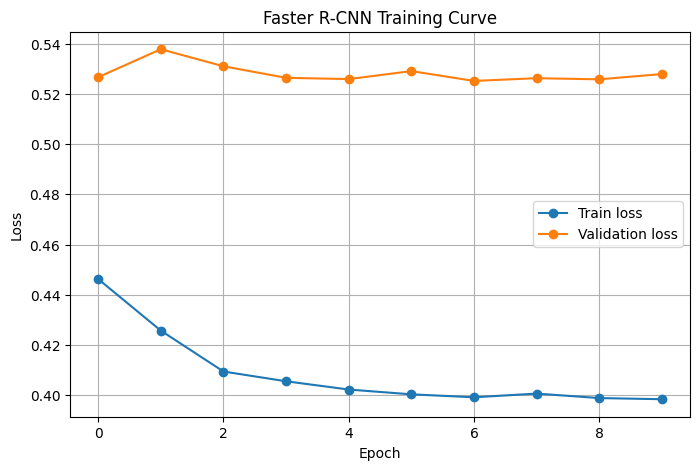

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss", marker="o")
plt.plot(val_losses, label="Validation loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model = get_faster_rcnn_model(NUM_CLASSES)
model.load_state_dict(torch.load("faster_rcnn_taco_best.pth", map_location=device))
model.to(device)
model.eval()

print("Best Faster R-CNN model loaded.")


Best Faster R-CNN model loaded.


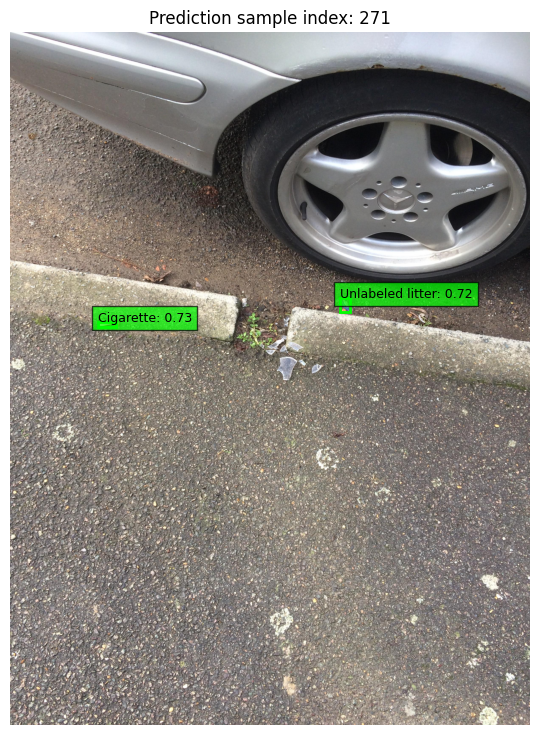

In [ ]:
@torch.no_grad()
def predict_sample(model, dataset, idx=None, score_thresh=0.5):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    image, target = dataset[idx]

    model.eval()
    prediction = model([image.to(device)])[0]

    image_np = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.imshow(image_np)

    for box, label, score in zip(
        prediction["boxes"],
        prediction["labels"],
        prediction["scores"]
    ):
        if score.item() < score_thresh:
            continue

        xmin, ymin, xmax, ymax = box.detach().cpu().tolist()
        w = xmax - xmin
        h = ymax - ymin

        original_cat_id = int(label.item()) - 1
        class_name = dataset.cat_id_to_name.get(original_cat_id, "unknown")

        rect = patches.Rectangle(
            (xmin, ymin),
            w,
            h,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            f"{class_name}: {score.item():.2f}",
            color="black",
            fontsize=9,
            bbox=dict(facecolor="lime", alpha=0.7)
        )

    ax.set_title(f"Prediction sample index: {idx}")
    ax.axis("off")
    plt.show()


predict_sample(model, test_dataset, score_thresh=0.5)


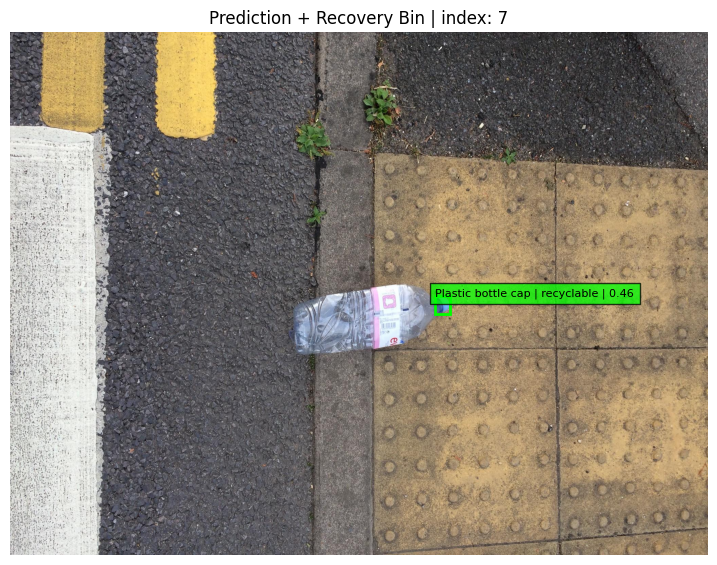

In [ ]:
@torch.no_grad()
def predict_sample_with_recovery_bin(model, dataset, idx=None, score_thresh=0.35):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    image, target = dataset[idx]

    model.eval()
    prediction = model([image.to(device)])[0]

    image_np = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.imshow(image_np)

    for box, label, score in zip(
        prediction["boxes"],
        prediction["labels"],
        prediction["scores"]
    ):
        score_value = score.item()

        if score_value < score_thresh:
            continue

        xmin, ymin, xmax, ymax = box.detach().cpu().tolist()
        w = xmax - xmin
        h = ymax - ymin

        original_cat_id = int(label.item()) - 1
        class_name = dataset.cat_id_to_name.get(original_cat_id, "unknown")

        recovery_bin = assign_recovery_bin(class_name, score_value)

        if recovery_bin == "recyclable":
            color = "lime"
        elif recovery_bin == "non_recyclable":
            color = "red"
        else:
            color = "yellow"

        rect = patches.Rectangle(
            (xmin, ymin),
            w,
            h,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            f"{class_name} | {recovery_bin} | {score_value:.2f}",
            color="black",
            fontsize=8,
            bbox=dict(facecolor=color, alpha=0.75)
        )

    ax.set_title(f"Prediction + Recovery Bin | index: {idx}")
    ax.axis("off")
    plt.show()


predict_sample_with_recovery_bin(model, test_dataset, score_thresh=0.35)


In [ ]:
import json
import torch
from tqdm.auto import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


@torch.no_grad()
def evaluate_coco_map_for_taco(model, data_loader, device, score_threshold=0.05):
    model.eval()

    gt_dict = {
        "images": [],
        "annotations": [],
        "categories": []
    }
    pred_list = []

    added_images = set()
    ann_id = 1
    used_cat_ids = set()

    for images, targets in tqdm(data_loader, desc="COCO eval"):
        images_device = [img.to(device) for img in images]
        outputs = model(images_device)
        outputs = [{k: v.detach().cpu() for k, v in out.items()} for out in outputs]

        for image, target, output in zip(images, targets, outputs):
            image_id = int(target["image_id"].item())

            if image_id not in added_images:
                h, w = image.shape[1], image.shape[2]
                gt_dict["images"].append({
                    "id": image_id,
                    "width": int(w),
                    "height": int(h)
                })
                added_images.add(image_id)

            gt_boxes = target["boxes"].cpu()
            gt_labels = target["labels"].cpu()
            gt_iscrowd = target["iscrowd"].cpu() if "iscrowd" in target else torch.zeros(len(gt_boxes), dtype=torch.int64)

            for i, (box, label) in enumerate(zip(gt_boxes, gt_labels)):
                xmin, ymin, xmax, ymax = box.tolist()
                bw = max(0.0, xmax - xmin)
                bh = max(0.0, ymax - ymin)

                cat_id = int(label.item())
                used_cat_ids.add(cat_id)

                gt_dict["annotations"].append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": cat_id,
                    "bbox": [float(xmin), float(ymin), float(bw), float(bh)],
                    "area": float(bw * bh),
                    "iscrowd": int(gt_iscrowd[i].item())
                })
                ann_id += 1

            keep = output["scores"] >= score_threshold
            pred_boxes = output["boxes"][keep]
            pred_scores = output["scores"][keep]
            pred_labels = output["labels"][keep]

            for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
                xmin, ymin, xmax, ymax = box.tolist()
                bw = max(0.0, xmax - xmin)
                bh = max(0.0, ymax - ymin)

                pred_list.append({
                    "image_id": image_id,
                    "category_id": int(label.item()),
                    "bbox": [float(xmin), float(ymin), float(bw), float(bh)],
                    "score": float(score.item())
                })

    gt_dict["categories"] = [
        {"id": int(cat_id), "name": f"class_{cat_id}"}
        for cat_id in sorted(used_cat_ids)
    ]

    print("Test images:", len(gt_dict["images"]))
    print("GT annotations:", len(gt_dict["annotations"]))
    print("Predictions:", len(pred_list))
    print("Used category ids:", sorted(used_cat_ids))

    if len(gt_dict["images"]) == 0:
        print("No test images found.")
        return None

    if len(gt_dict["annotations"]) == 0:
        print("No ground truth annotations found.")
        return None

    if len(pred_list) == 0:
        print("No predictions above threshold. Try lower score_threshold.")
        return None

    coco_gt = COCO()
    coco_gt.dataset = gt_dict
    coco_gt.createIndex()

    with open("coco_test_ground_truth.json", "w") as f:
        json.dump(gt_dict, f)

    with open("coco_test_predictions.json", "w") as f:
        json.dump(pred_list, f)

    coco_dt = coco_gt.loadRes("coco_test_predictions.json")

    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.imgIds = sorted(list(added_images))
    coco_eval.params.catIds = sorted(list(used_cat_ids))
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics = {
        "AP@[0.50:0.95]": float(coco_eval.stats[0]),
        "AP50": float(coco_eval.stats[1]),
        "AP75": float(coco_eval.stats[2]),
        "AP_small": float(coco_eval.stats[3]),
        "AP_medium": float(coco_eval.stats[4]),
        "AP_large": float(coco_eval.stats[5]),
        "AR@1": float(coco_eval.stats[6]),
        "AR@10": float(coco_eval.stats[7]),
        "AR@100": float(coco_eval.stats[8]),
        "AR_small": float(coco_eval.stats[9]),
        "AR_medium": float(coco_eval.stats[10]),
        "AR_large": float(coco_eval.stats[11]),
    }

    return metrics


In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
    collate_fn=collate_fn
)

test_metrics = evaluate_coco_map_for_taco(
    model=model,
    data_loader=test_loader,
    device=device,
    score_threshold=0.05
)

if test_metrics is not None:
    print("\nTest Metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")


COCO eval:   0%|          | 0/298 [00:00<?, ?it/s]

Test images: 298
GT annotations: 889
Predictions: 6597
Used category ids: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 32, 33, 34, 35, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
creating index...
index created!
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.64s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.068
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.022
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.

In [ ]:
def box_iou_matrix(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]))

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-9)


@torch.no_grad()
def evaluate_precision_recall_f1(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    model.eval()

    TP, FP, FN = 0, 0, 0

    for images, targets in tqdm(data_loader, desc="PR/F1 eval"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            pred_boxes = output["boxes"].detach().cpu()
            pred_scores = output["scores"].detach().cpu()
            pred_labels = output["labels"].detach().cpu()

            gt_boxes = target["boxes"].detach().cpu()
            gt_labels = target["labels"].detach().cpu()

            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_scores = pred_scores[keep]

            if pred_scores.numel() > 0:
                order = torch.argsort(pred_scores, descending=True)
                pred_boxes = pred_boxes[order]
                pred_labels = pred_labels[order]

            matched_gt = torch.zeros(len(gt_boxes), dtype=torch.bool)

            for pb, pl in zip(pred_boxes, pred_labels):
                candidate_idx = torch.where((gt_labels == pl) & (~matched_gt))[0]

                if candidate_idx.numel() == 0:
                    FP += 1
                    continue

                ious = box_iou_matrix(pb.unsqueeze(0), gt_boxes[candidate_idx]).squeeze(0)
                best_iou, best_pos = torch.max(ious, dim=0)

                if float(best_iou) >= iou_threshold:
                    TP += 1
                    matched_gt[candidate_idx[int(best_pos)]] = True
                else:
                    FP += 1

            FN += int((~matched_gt).sum().item())

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


pr_metrics = evaluate_precision_recall_f1(
    model=model,
    data_loader=test_loader,
    device=device,
    iou_threshold=0.5,
    score_threshold=0.5
)

print("\nPR / F1 Metrics:")
for k, v in pr_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")


PR/F1 eval:   0%|          | 0/298 [00:00<?, ?it/s]


PR / F1 Metrics:
TP: 65
FP: 161
FN: 824
Precision: 0.2876
Recall: 0.0731
F1: 0.1166
